In [7]:
%load_ext autoreload
%autoreload 2

from folde.util import load_checkpointed_model_eval, convert_compaign_result_collection_to_df, DMS_SHORTNAMES
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

results = load_checkpointed_model_eval(
    'notebooks/jacob/model_evals/',
    '250716-r1-explore-exploit-tension',
    []
)
mutant_df, round_metrics_df = convert_compaign_result_collection_to_df(results)
round_metrics_df['dms_shortname'] = round_metrics_df.dms_id.apply(lambda x: DMS_SHORTNAMES[x])

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Loading results for DMSs: {'BLAT_ECOLX_Firnberg_2014', 'SHOC2_HUMAN_Kwon_2022', 'HEM3_HUMAN_Loggerenberg_2023', 'CBS_HUMAN_Sun_2020', 'OXDA_RHOTO_Vanella_2023_activity', 'HSP82_YEAST_Flynn_2019', 'HXK4_HUMAN_Gersing_2022_activity', 'PPM1D_HUMAN_Miller_2022', 'ANCSZ_Hobbs_2022'}


<Axes: xlabel='round_num', ylabel='held_out_10pct_recall'>

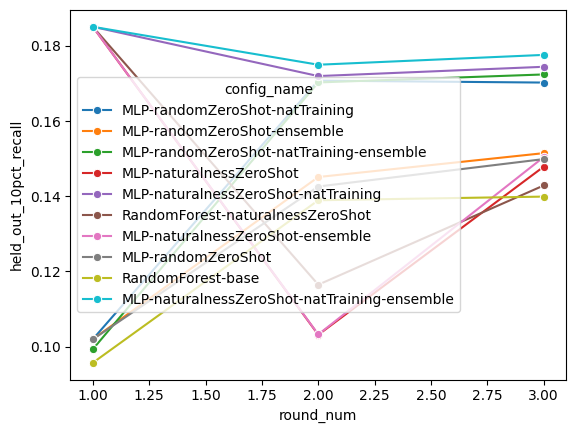

In [8]:
sns.lineplot(
    data=round_metrics_df,
    # y='held_out_activity_spearman',
    y='held_out_10pct_recall',
    # y='held_out_1pct_auc',
    # y='held_out_activity_spearman',
    x='round_num',
    hue='config_name',
    errorbar=None,
    marker='o',
    # style='config_name',
    # errorbar=None
)

Text(0.5, 0, '')

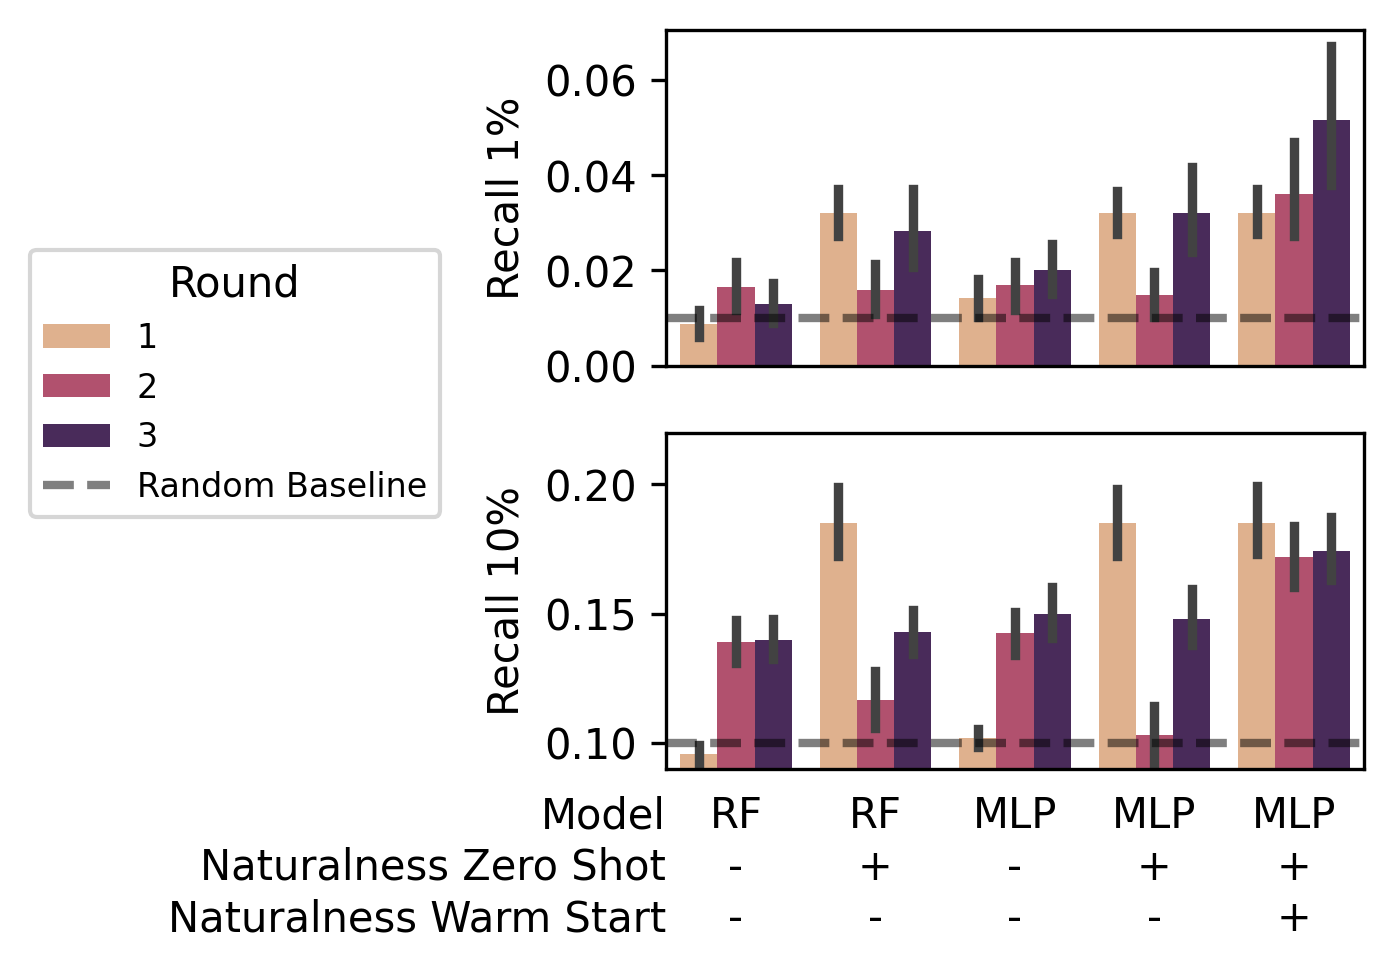

In [64]:
configs = [
    ('RandomForest-base', 'RandomForest + Random First Round'),
    ('RandomForest-naturalnessZeroShot', 'RandomForest + Naturalness First Round'),
    ('MLP-randomZeroShot', 'MLP + Random First Round'),
    ('MLP-naturalnessZeroShot', 'MLP + Naturalness First Round'),
    ('MLP-naturalnessZeroShot-natTraining', 'MLP + Naturalness First Round +\nTraining'),
    # ('MLP-randomZeroShot-natTraining', 'Random First Round +\nTraining'),
]

plot_df = round_metrics_df.copy()
plot_df['config_name'] = plot_df['config_name'].apply(lambda x: dict(configs).get(x, x))
plot_df['Round'] = plot_df['round_num']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(3, 3.2), sharex=True, dpi=300)

for ax, metric in zip([ax1, ax2], [ 'held_out_1pct_recall', 'held_out_10pct_recall']):
    sns.barplot(
        ax=ax,
        data=plot_df[(plot_df.round_num <= 3) & (plot_df.config_name.isin([c for _, c in configs]))],
        x='config_name',
        y=metric,
        hue='Round',
        order=[c for _, c in configs],
        palette='flare'
    )

treatment_matrix = [
    ['RF', 'RF', 'MLP', 'MLP', 'MLP'],
    ['-', '+', '-', '+', '+'],
    ['-', '-', '-', '-', '+'],
]

row_labels = ['Model', 'Naturalness Zero Shot', 'Naturalness Warm Start']
for i, label in enumerate(row_labels):
    y = 0.08 - i * 0.02  # control vertical spacing
    for j, sym in enumerate(treatment_matrix[i]):
        ax2.text(j, y, sym, ha='center', va='top', fontsize=10)
    # Optional: add row label on the left
    ax2.text(-0.5, y, label, ha='right', va='top', fontsize=10)

# Clean up plot
# ax1.set_ylim(0.09, 0.22)
ax1.set_ylabel('Recall 1%')
ax1.axhline(y=0.01, color='black', linewidth=2, alpha=0.5, linestyle='--', label='Random Baseline')


ax2.set_ylim(0.09, 0.22)
ax2.set_ylabel('Recall 10%')
# ax.spines['bottom'].set_visible(False)
ax2.tick_params(axis='x', length=0)
ax2.set_xticks([])  # hide original x-axis labels if desired
ax2.axhline(y=0.1, color='black', linewidth=2, alpha=0.5, linestyle='--', label='Random Baseline')


ax1.legend(
    title='Round',
    loc='lower right',
    bbox_to_anchor=(-0.3, -0.5),
    fontsize=8,

)
ax2.get_legend().remove()

ax1.set_xlabel('')

ax2.set_xlabel('')

In [40]:
plot_df.groupby(['config_name', 'round_num']).held_out_10pct_recall.mean()

config_name                                   round_num
MLP + Naturalness First Round                 1            0.185041
                                              2            0.103183
                                              3            0.147865
MLP + Naturalness First Round +\nTraining     1            0.185041
                                              2            0.171937
                                              3            0.174406
MLP + Random First Round                      1            0.101985
                                              2            0.142584
                                              3            0.149871
MLP-naturalnessZeroShot-ensemble              1            0.185041
                                              2            0.103258
                                              3            0.150414
MLP-naturalnessZeroShot-natTraining-ensemble  1            0.185041
                                              2            0

In [43]:
(0.142584 - 0.103183) / 0.142584

0.2763353531953094